In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.EDA.data_preprocessing import data_preprocessing, extract_features
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

df0 = pd.read_parquet('../datasets/train_data/train_data_0.pq')

from src.schema import category_cols, binary_cols

df0 = extract_features(df=data_preprocessing(df0, category_cols=category_cols, binary_cols=binary_cols), category_cols=category_cols, binary_cols=binary_cols)

In [16]:
dft = pd.read_csv('../datasets/train_target.csv')
df0 = df0.merge(right=dft, how='left', on='id')

Посчитаем корреляцию каждого признака с flag

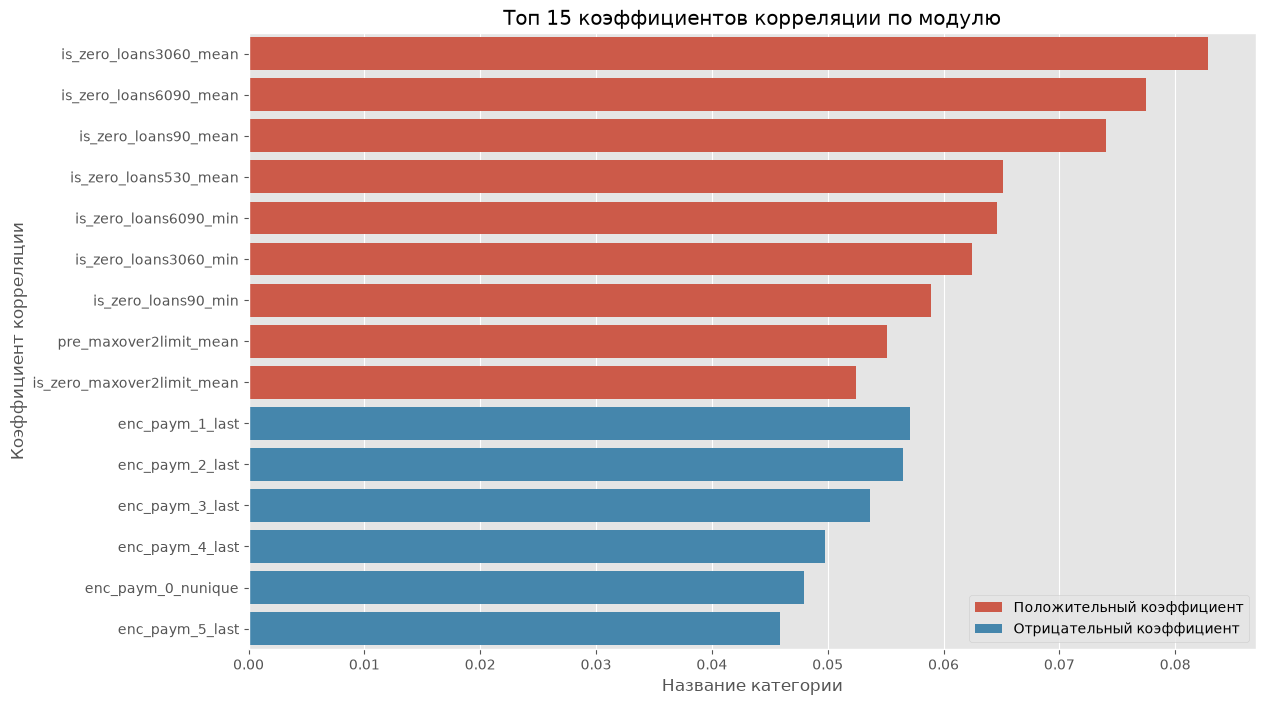

In [63]:
features = df0.drop(columns=['id', 'flag'], errors='ignore')
correlations = features.corrwith(df0['flag'])
top_correlations = correlations.abs().sort_values(ascending=False)
res = correlations.loc[top_correlations.index].head(15)
res1, res2 = -res[res < 0], res[res > 0]

plt.figure(figsize=(13, 8))
sns.barplot(y=res1.index, x=res1.values, color='C0', label='Положительный коэффициент')
sns.barplot(y=res2.index, x=res2.values, color='C1', label='Отрицательный коэффициент')
plt.legend(loc='lower right')
plt.xlabel('Название категории')
plt.ylabel('Коэффициент корреляции')
plt.title('Топ 15 коэффициентов корреляции по модулю')
plt.show()